# Resume Dataset Analysis

This notebook performs exploratory data analysis on the Resume dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
data_path = "../data/raw/resume_dataset/training_data.csv"
df = pd.read_csv(data_path)
df.head()

,Resume ID,Resume Text,Education,Experience Years,Skills,Job Role,Category
0,R000000,Education: Bachelor's in Computer Science Expe...,Bachelor's in Computer Science,2,Market Research|Maven|Java|REST API|Spring Boo...,Java Backend Developer,Technology
1,R000001,Education: Master's in Microbiology Experience...,Master's in Microbiology,3,Agile|Data Analysis|Precision|Problem Solving|...,Microbiologist,Science & Research
2,R000002,Education: Apprenticeship Experience: 2 years ...,Apprenticeship,2,React|Customer Service|Technical Knowledge|Plu...,Plumber,Skilled Trades
3,R000003,Education: Bachelor's in Computer Science Expe...,Bachelor's in Computer Science,0,MySQL|Query Optimization|Symfony|Terraform|PHP...,PHP Developer,Technology
4,R000004,Education: Bachelor's in Design Experience: 3 ...,Bachelor's in Design,3,Problem Solving|Docker|Creativity|Scrum|Ansibl...,Art Director,Creative & Design


In [3]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

Shape: (10000, 7)

Columns: ['Resume ID', 'Resume Text', 'Education', 'Experience Years', 'Skills', 'Job Role', 'Category']


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Resume ID         10000 non-null  str  
 1   Resume Text       10000 non-null  str  
 2   Education         10000 non-null  str  
 3   Experience Years  10000 non-null  int64
 4   Skills            10000 non-null  str  
 5   Job Role          10000 non-null  str  
 6   Category          10000 non-null  str  
dtypes: int64(1), str(6)
memory usage: 547.0 KB


In [5]:
print("Missing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
 Resume ID           0
Resume Text         0
Education           0
Experience Years    0
Skills              0
Job Role            0
Category            0
dtype: int64

Duplicate Rows: 0


In [6]:
df.describe(include='all')

,Resume ID,Resume Text,Education,Experience Years,Skills,Job Role,Category
count,10000,10000,10000,10000.000000,10000,10000,10000
unique,10000,10000,257,NaN,10000,324,42
top,R000000,Education: Bachelor's in Computer Science Expe...,Bachelor's in Computer Science,NaN,Market Research|Maven|Java|REST API|Spring Boo...,Java Backend Developer,Technology
freq,1,1,1425,NaN,1,50,2511
mean,NaN,NaN,NaN,3.133800,NaN,NaN,NaN
std,NaN,NaN,NaN,2.180269,NaN,NaN,NaN
min,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,2.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,3.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,4.000000,NaN,NaN,NaN


In [7]:
print("Unique Categories:", df['Category'].nunique())
print("Unique Job Roles:", df['Job Role'].nunique())

Unique Categories: 42
Unique Job Roles: 324


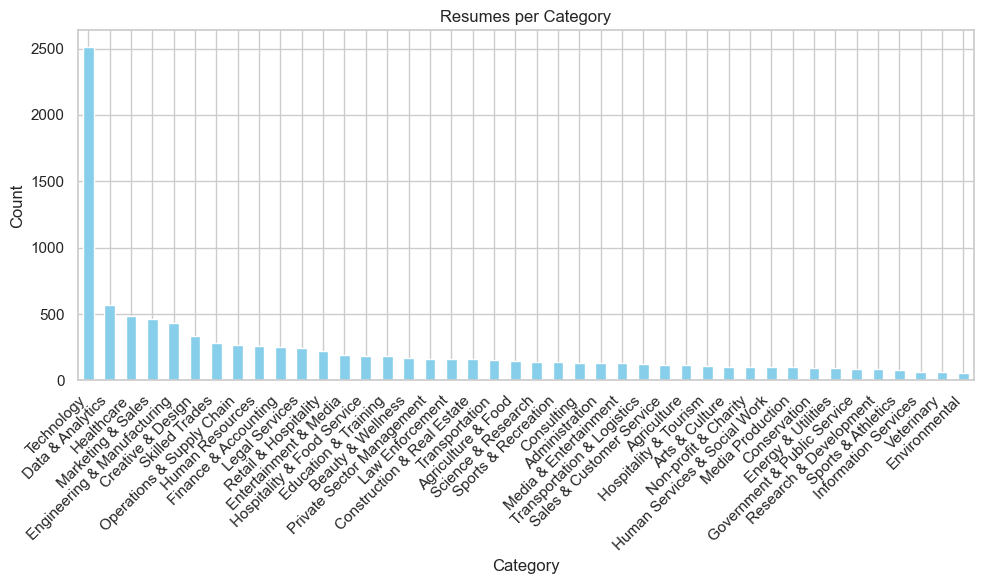

In [8]:
plt.figure(figsize=(10, 6))
df['Category'].value_counts().plot(kind='bar', color='skyblue')
plt.title("Resumes per Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

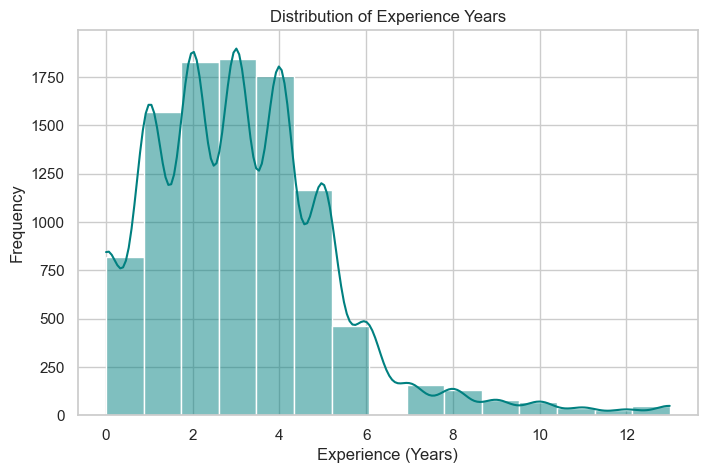

In [9]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Experience Years'], bins=15, kde=True, color='teal')
plt.title("Distribution of Experience Years")
plt.xlabel("Experience (Years)")
plt.ylabel("Frequency")
plt.show()

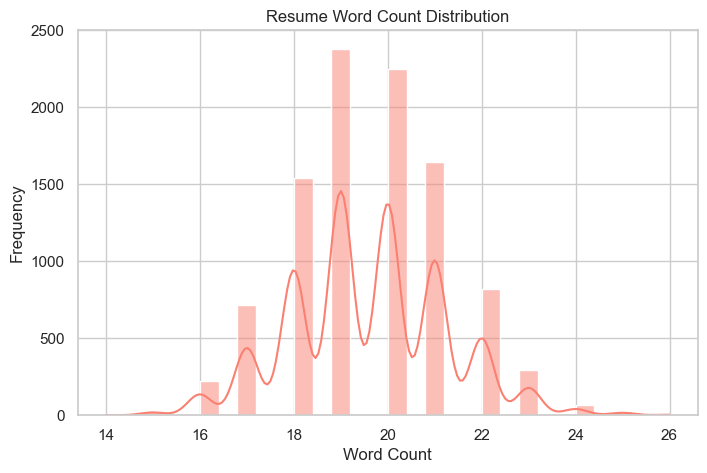

In [10]:
df['resume_length'] = df['Resume Text'].fillna("").apply(len)
df['word_count'] = df['Resume Text'].fillna("").apply(lambda x: len(x.split()))

plt.figure(figsize=(8, 5))
sns.histplot(df['word_count'], bins=30, kde=True, color='salmon')
plt.title("Resume Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

In [11]:
print("Average word count:", df['word_count'].mean())
print("Median word count:", df['word_count'].median())

Average word count: 19.5924
Median word count: 20.0


### Conclusion

- The dataset contains 10,000 resume records.
- There are no missing values and no duplicate rows.
- Resumes cover several categories and job roles, providing a broad distribution of candidate profiles.
- The text length is relatively consistent across resumes, suggesting they may follow a specific template or structure.
- Skills are separated by pipes (`|`) and will need parsing for deeper skill extraction tasks.